Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00,  7.80it/s]


<diode_front>
<diode_up>
<resistor_front>
<resistor_up>


100%|██████████| 50/50 [00:01<00:00, 27.21it/s]


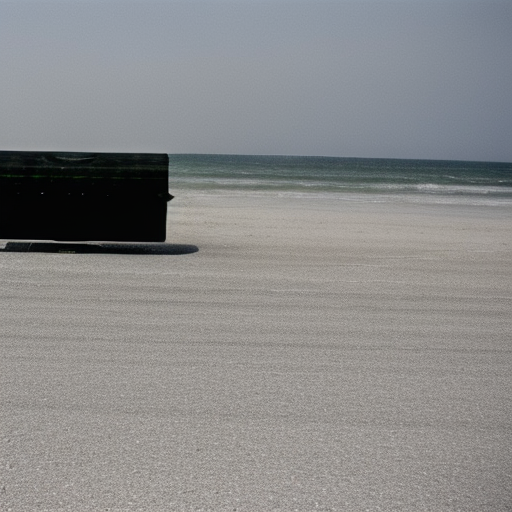

In [ ]:
from diffusers import StableDiffusionPipeline, EulerAncestralDiscreteScheduler
from lora_diffusion.lora import tune_lora_scale, patch_pipe
import torch

model_id = "/root/stable-diffusion-2-1-base"

pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to(
    "cuda:6"
)
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)

# pipe1 = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to(
#     "cuda:2"
# )

prompt = "a photo of a great <green_light_diode_front>"

# patch_pipe(
#     pipe1,
#     # "/root/lora_train/nut_right/final_lora/final_step_1000.safetensors",
#     "/root/custom_example/new_experiment/nut_new_ex/up/final_lora.safetensors",
#     patch_text=True,
#     patch_ti=True,
#     patch_unet=True,
# )

patch_pipe(
    pipe,
    # "/root/lora_train/nut_right/final_lora/final_step_1000.safetensors",
    # "/root/lora_train/combine15/final_lora/final_step_5000.safetensors",
    # "/root/lora_train/multi_combine_20250617_211727/multi_teacher_distilled/final_multi_teacher_lora_step_5000.safetensors",
    # "/root/lora_train/multi_combine_20250623_113607/multi_teacher_distilled/final_multi_teacher_lora_step_5000.safetensors",
    # "/root/custom_example/dis_lora_weight/gasket_up.safetensors",
    # "/root/custom_example/dis_lora_weight/nail.safetensors",
    # "/root/custom_example/dis_lora_weight/nut_front.safetensors",
    # "/root/custom_example/dis_lora_weight/nut_up.safetensors",
    # "/root/custom_example/dis_lora_weight/screw_front.safetensors",
    # "/root/custom_example/dis_lora_weight/screw_up.safetensors",
    # "/root/custom_example/dis_lora_weight/screw_combine_lora.safetensors",
    # "/root/custom_example/dis_lora_weight/nut_combine_lora.safetensors",
    # "/root/custom_example/dis_lora_weight/nail_and_gasket_lora.safetensors",
    # "/root/lora_train/multi_combine_20250703_172203/multi_teacher_distilled/final_multi_teacher_hybrid_lora_step_5000.safetensors",
    # "/root/lora_train/multi_combine_20250716_233014/multi_teacher_distilled/final_multi_teacher_hybrid_lora_step_5000.safetensors",
    # "/root/lora_weight_before_distill/ceramic_capacitor_front_5000/final_lora.safetensors",
    # "/root/lora_train/multi_combine_20250717_182011/multi_teacher_distilled/final_multi_teacher_hybrid_lora_step_5000.safetensors",
    # "/root/lora_train/multi_combine_20250717_175353/multi_teacher_distilled/final_multi_teacher_hybrid_lora_step_5000.safetensors",
    # "/root/lora_train/multi_combine_20250717_175343/multi_teacher_distilled/final_multi_teacher_hybrid_lora_step_5000.safetensors",
    # "/root/lora_weight_before_distill/distill_weight3/plastic_washer_up.safetensors",
    # "/root/lora_train/multi_combine_20250717_205233/multi_teacher_distilled/final_multi_teacher_hybrid_lora_step_5000.safetensors",
    # "/root/lora_train/multi_combine_20250721_111642/multi_teacher_distilled/final_multi_teacher_hybrid_lora_step_5000.safetensors",
    # "/root/lora_train/multi_combine_add/resistor_diode2.safetensors",
    "/root/lora_train/multi_combine_20250725_210930/multi_teacher_distilled/final_multi_teacher_hybrid_lora_step_5000.safetensors",
    patch_text=True,
    patch_ti=True,
    patch_unet=True,
)

# pipe.text_encoder = pipe1.text_encoder

tune_lora_scale(pipe.unet, 1.0)
tune_lora_scale(pipe.text_encoder, 1.0)

torch.manual_seed(42)
image = pipe(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]
image.save("../contents/lion_illust.jpg")
image
